In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src" / "finetune").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("project root:", ROOT)

import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from src.finetune import ensure_cyrillic, load_iam, TsvLineDataset, HFLineDataset

cfg = OmegaConf.load(ROOT / "configs" / "finetune.yaml")

project root: /workspace/HDD/handwriting-recognition/recognition


In [2]:
def show(dataset, n=6, title=""):
    n = min(n, len(dataset))
    if n == 0:
        print(f"{title}: empty"); return
    fig, axes = plt.subplots(n, 1, figsize=(12, 1.4 * n))
    axes = [axes] if n == 1 else axes
    for ax, i in zip(axes, range(n)):
        s = dataset[i]
        ax.imshow(s["image"]); ax.axis("off")
        ax.set_title(s["text"], fontsize=10, loc="left")
    fig.suptitle(title); plt.tight_layout(); plt.show()

def show_tsv(folder, glob, build_hint, title, subdir=""):
    tsv = next((ROOT / folder).glob(glob), None)
    if tsv is None:
        print(f"{title} not built -> {build_hint}")
        return
    ds = TsvLineDataset(tsv, tsv.parent, subdir)
    print(f"{title}: {len(ds)} lines (tsv: {tsv})")
    show(ds, title=title)

cyrillic train/test: 72284 1544


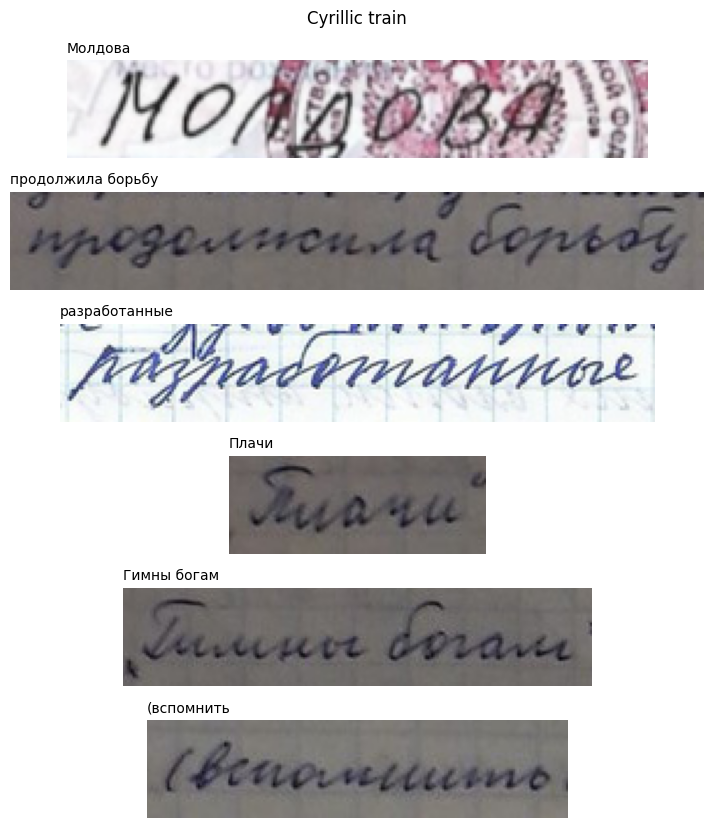

In [3]:
cyr_root = ROOT / cfg.data.sources.cyrillic.root
if next(cyr_root.glob("**/train.tsv"), None) is None:
    print(f"cyrillic not built -> python scripts/download/cyrillic.py --root {cfg.data.sources.cyrillic.root}")
else:
    cyr = ensure_cyrillic(cyr_root)
    cyr_train = TsvLineDataset(cyr.train_tsv, cyr.root, "train")
    cyr_test = TsvLineDataset(cyr.test_tsv, cyr.root, "test")
    print("cyrillic train/test:", len(cyr_train), len(cyr_test))
    show(cyr_train, title="Cyrillic train")

iam train/test: 7458 2915


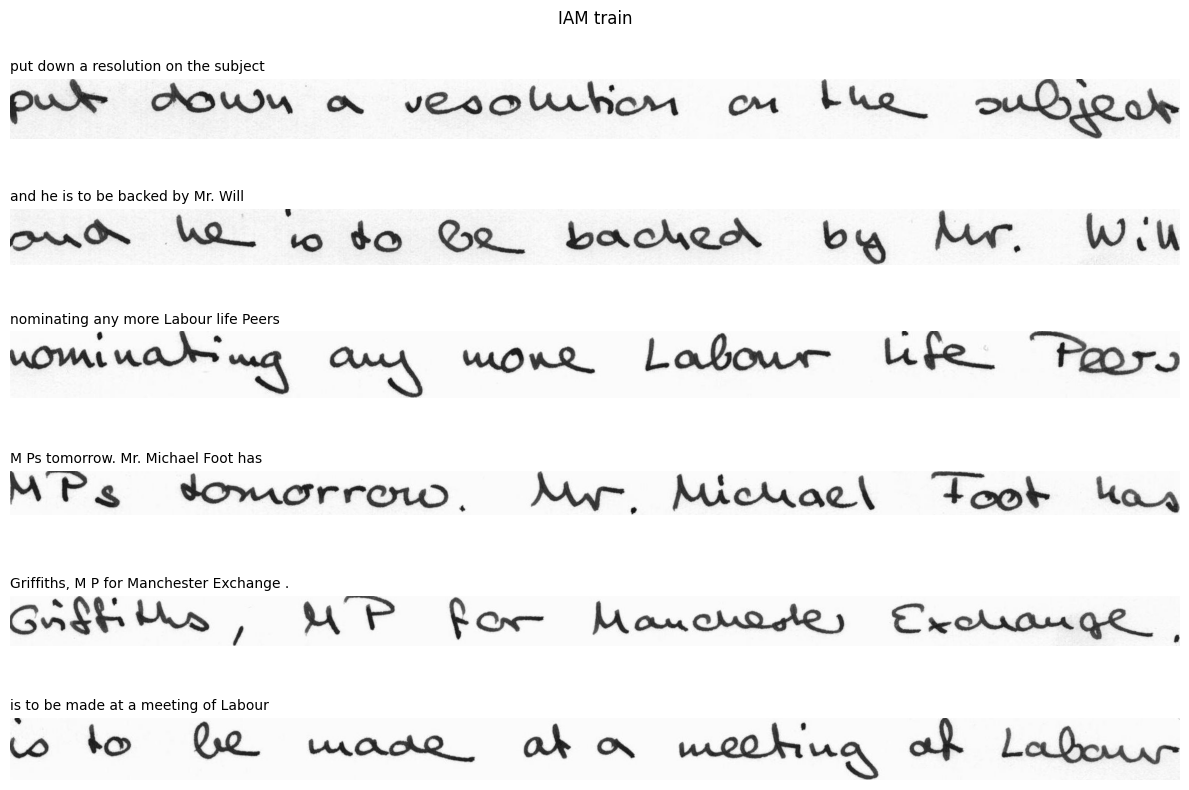

In [4]:
iam = load_iam(cfg.data.sources.get("iam"))
print("iam train/test:", len(iam.train) if iam else 0, len(iam.test) if iam and iam.test else 0)
if iam:
    show(HFLineDataset(iam.train, iam.image_key, iam.text_key), title="IAM train")

CVL (English): 13441 lines (tsv: /workspace/HDD/handwriting-recognition/recognition/data/cvl/cvl-database-1-1/cvl_train.tsv)


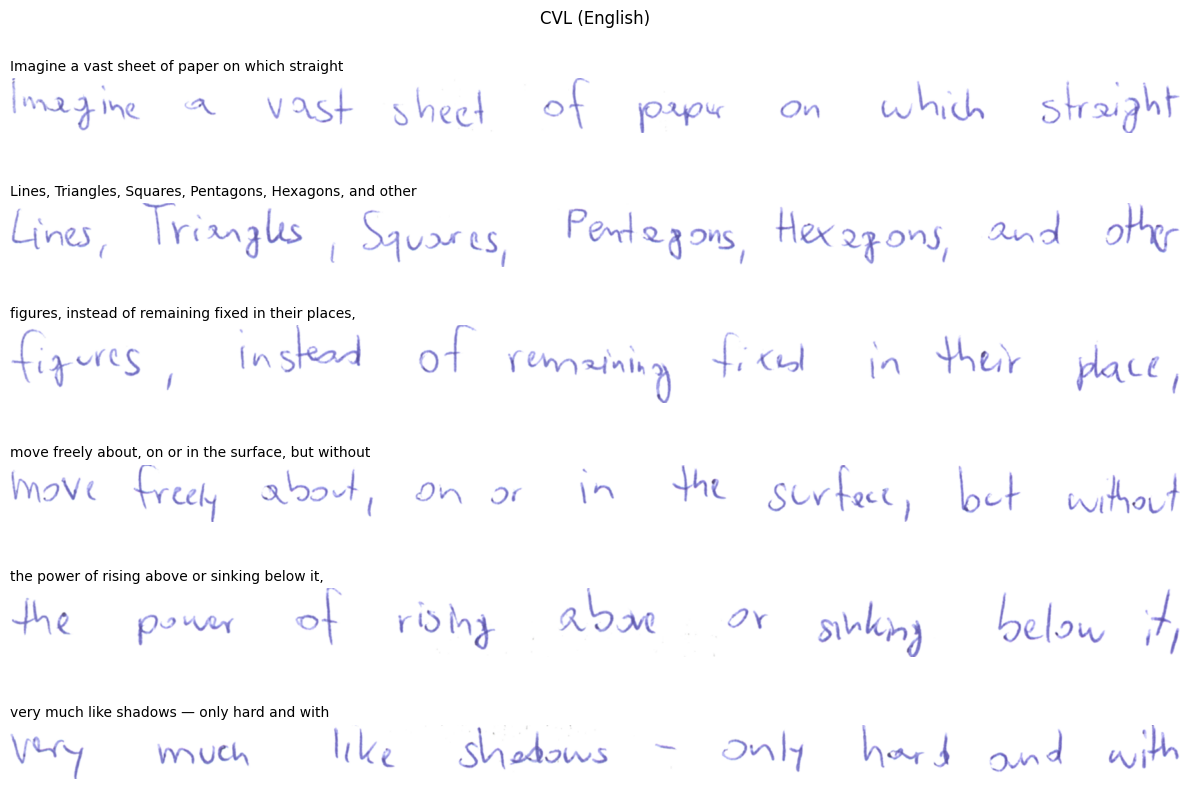

In [5]:
cvl = cfg.data.sources.cvl
show_tsv(cvl.root, cvl.train_glob, f"python scripts/download/cvl.py --root {cvl.root}", "CVL (English)")

School Notebooks RU: 61781 lines (tsv: /workspace/HDD/handwriting-recognition/recognition/data/school_notebooks_ru/train.tsv)


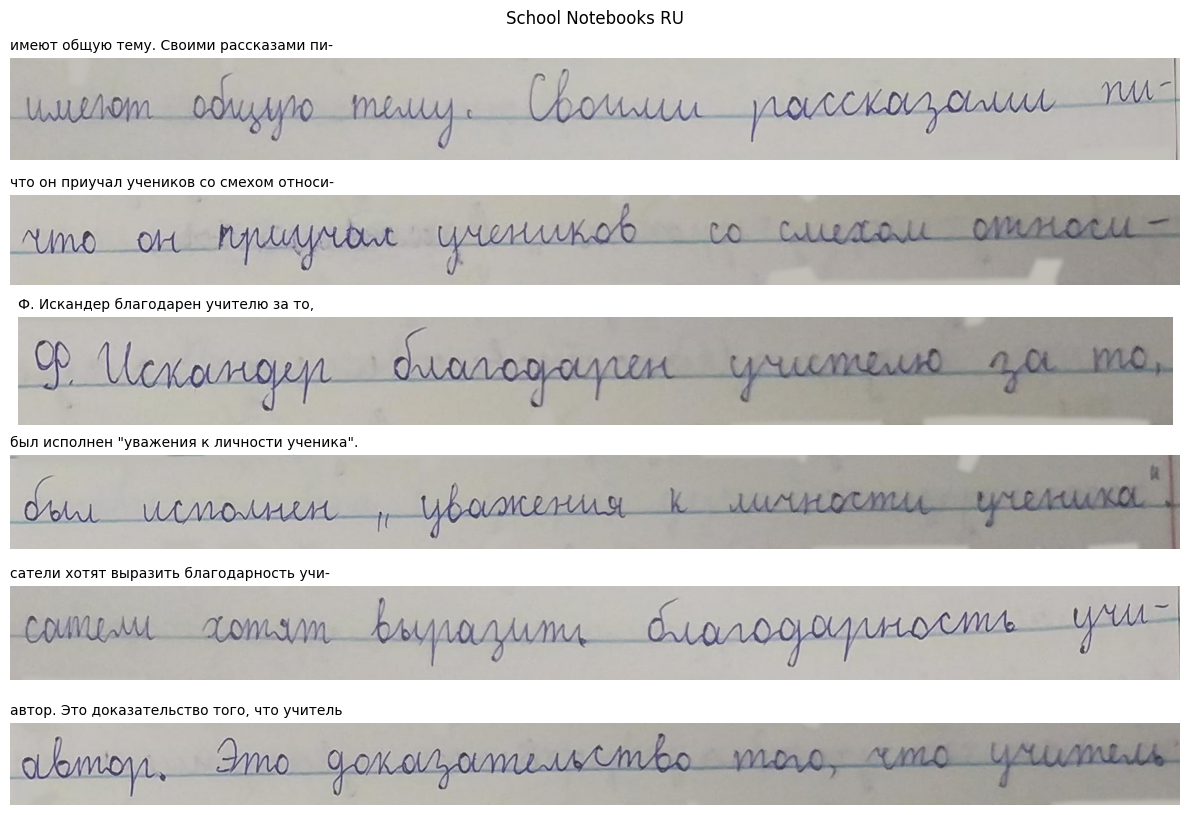

In [6]:
snr = cfg.data.sources.school_notebooks_ru
show_tsv(snr.root, snr.train_glob, "python scripts/download/all.py --datasets school_notebooks_ru", "School Notebooks RU")

School Notebooks EN: 2151 lines (tsv: /workspace/HDD/handwriting-recognition/recognition/data/school_notebooks_en/train.tsv)


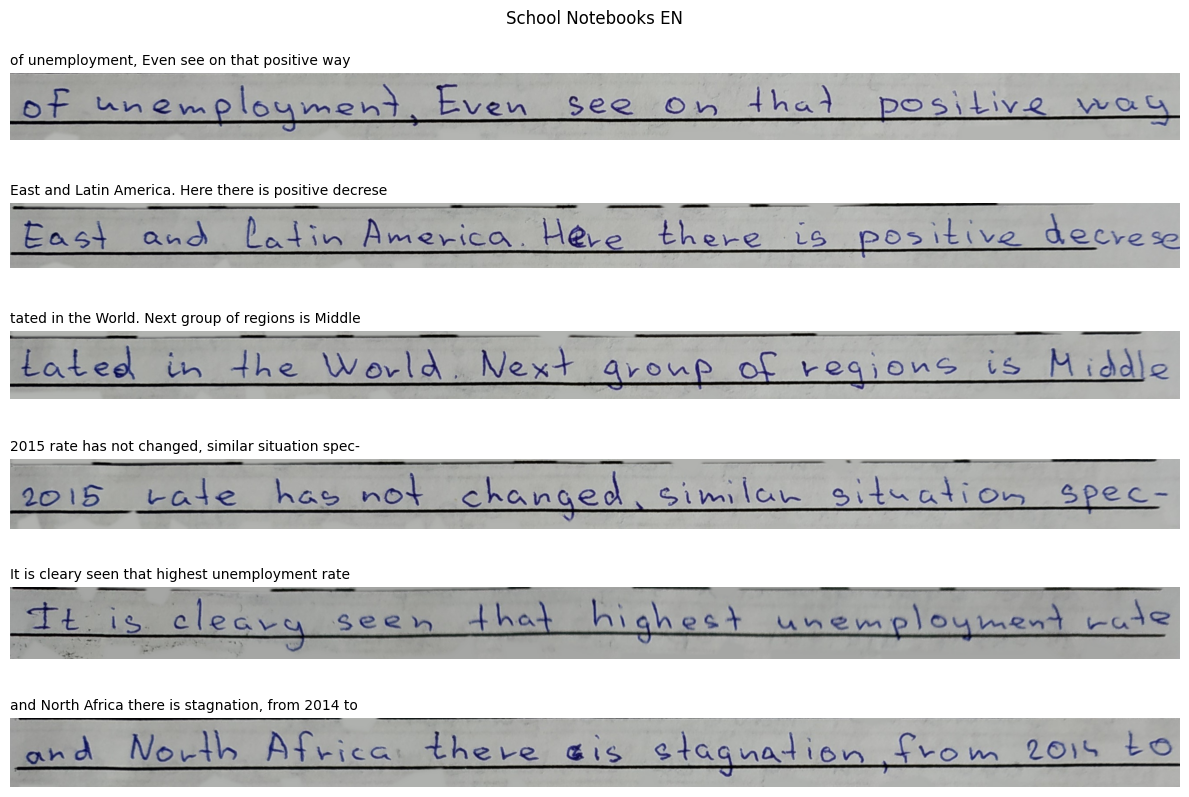

In [7]:
sne = cfg.data.sources.school_notebooks_en
show_tsv(sne.root, sne.train_glob, "python scripts/download/all.py --datasets school_notebooks_en", "School Notebooks EN")

In [8]:
print("lines per tsv:")
for name, s in cfg.data.sources.items():
    root = s.get("root")
    if not root:
        continue
    for tsv in sorted((ROOT / root).glob("**/*.tsv")):
        n = sum(1 for line in open(tsv, encoding="utf-8") if line.strip())
        print(f"  {tsv.relative_to(ROOT)}: {n}")

lines per tsv:
  data/cyrillic/test.tsv: 1544
  data/cyrillic/train.tsv: 72286
  data/school_notebooks_ru/test.tsv: 5468
  data/school_notebooks_ru/train.tsv: 61781
  data/cvl/cvl-database-1-1/cvl_train.tsv: 13441
  data/school_notebooks_en/test.tsv: 246
  data/school_notebooks_en/train.tsv: 2151


In [1]:
import re, requests

url = "https://ieee-dataport.org/documents/russian-cursive-handwriting-rch-dataset"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text
links = sorted(set(re.findall(r'https://[^"\'<> ]*s3[^"\'<> ]*amazonaws[^"\'<> ]*', html)))
print(*links, sep="\n")          # прямые ссылки на файлы (если open-access)

for u in links:
    name = u.split("/")[-1].split("?")[0]
    with requests.get(u, stream=True, headers={"User-Agent": "Mozilla/5.0"}) as r:
        r.raise_for_status()
        with open(name, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
    print("saved", name)

In [2]:
links

[]